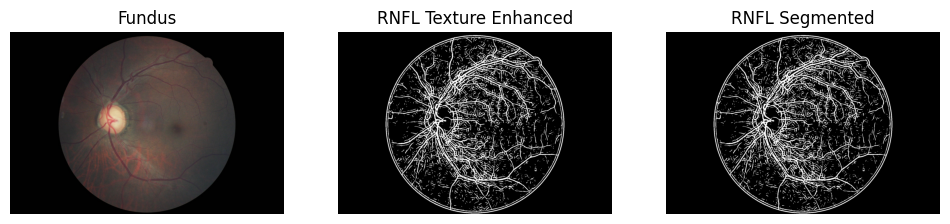

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import gabor

# Load and preprocess
img = cv2.imread("retina.jpg")
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
green = rgb[:,:,1]

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(green)

# Apply Gabor filter to capture RNFL oriented fibers
rnfl = np.zeros_like(enhanced, dtype=np.float32)
for theta in range(0, 180, 15): 
    filt_real, _ = gabor(enhanced, frequency=0.1, theta=np.deg2rad(theta))
    rnfl = np.maximum(rnfl, filt_real)

# Normalize for display
rnfl_norm = cv2.normalize(rnfl, None, 0, 255, cv2.NORM_MINMAX)
rnfl_norm = rnfl_norm.astype(np.uint8)

# Threshold to highlight RNFL regions
_, rnfl_bin = cv2.threshold(rnfl_norm, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

plt.figure(figsize=(12,6))
plt.subplot(1,3,1); plt.imshow(rgb); plt.title("Fundus")
plt.axis("off")
plt.subplot(1,3,2); plt.imshow(rnfl_norm, cmap="gray"); plt.title("RNFL Texture Enhanced")
plt.axis("off")
plt.subplot(1,3,3); plt.imshow(rnfl_bin, cmap="gray"); plt.title("RNFL Segmented")
plt.axis("off")
plt.show()


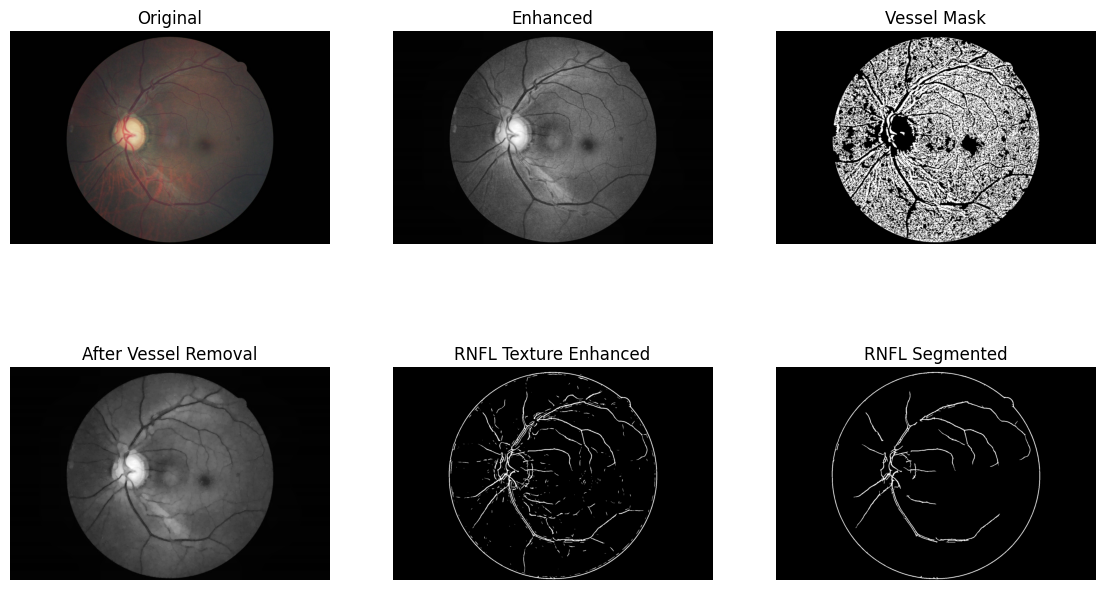

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import gabor
from skimage.morphology import remove_small_objects

# ---- Load Image ----
img = cv2.imread("retina.jpg")
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
green = rgb[:, :, 1]  # green channel for RNFL

# ---- Enhance ----
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(green)

# ---- Blood Vessel Extraction (Top-hat + threshold) ----
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15,15))
top_hat = cv2.morphologyEx(enhanced, cv2.MORPH_TOPHAT, kernel)

_, vessel_mask = cv2.threshold(top_hat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Clean tiny noise from vessel mask
vessel_mask_clean = remove_small_objects(vessel_mask.astype(bool), min_size=200)
vessel_mask_clean = (vessel_mask_clean * 255).astype(np.uint8)

# Subtract vessel signal → RNFL texture remains
no_vessels = cv2.inpaint(enhanced, vessel_mask_clean, 3, cv2.INPAINT_TELEA)

# ---- RNFL TEXTURE DETECTION (Gabor Filters) ----
rnfl = np.zeros_like(no_vessels, dtype=np.float32)

for theta in range(0, 180, 15):  # multi-orientation filter bank
    filt_real, _ = gabor(no_vessels, frequency=0.12, theta=np.deg2rad(theta))
    rnfl = np.maximum(rnfl, filt_real)

# Normalize for display
rnfl_norm = cv2.normalize(rnfl, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# ---- Final RNFL Thresholding ----
_, rnfl_mask = cv2.threshold(rnfl_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Remove remaining noise
rnfl_mask = remove_small_objects(rnfl_mask.astype(bool), min_size=500)
rnfl_mask = (rnfl_mask * 255).astype(np.uint8)

# ---- Output ----
plt.figure(figsize=(14,8))
plt.subplot(2,3,1), plt.imshow(rgb); plt.title("Original"); plt.axis("off")
plt.subplot(2,3,2), plt.imshow(enhanced, cmap='gray'); plt.title("Enhanced"); plt.axis("off")
plt.subplot(2,3,3), plt.imshow(vessel_mask_clean, cmap='gray'); plt.title("Vessel Mask"); plt.axis("off")
plt.subplot(2,3,4), plt.imshow(no_vessels, cmap='gray'); plt.title("After Vessel Removal"); plt.axis("off")
plt.subplot(2,3,5), plt.imshow(rnfl_norm, cmap='gray'); plt.title("RNFL Texture Enhanced"); plt.axis("off")
plt.subplot(2,3,6), plt.imshow(rnfl_mask, cmap='gray'); plt.title("RNFL Segmented"); plt.axis("off")
plt.show()
